# Proyek Analisis dan Klasifikasi Tutupan Lahan (LULC) Satelit Sentinel-2 Jawa Timur

## Deskripsi Singkat
Notebook ini berisi alur kerja komprehensif untuk pemrosesan data spektral satelit, agregasi centroid poligon, pembagian dataset training/testing, pembuatan peta interaktif GIS, Exploratory Data Analysis (EDA) karakteristik spektral, pemodelan Machine Learning menggunakan Support Vector Machine (SVM), hingga evaluasi dan ekspor model.

### 5 Kelas Tutupan Lahan Target:
1. **Air:** Danau, laut, sungai, dan tambak.
2. **Hutan Mangrove:** Vegetasi pesisir pantai dan muara.
3. **Hutan Non-Mangrove:** Vegetasi pepohonan daratan / hutan rimba.
4. **Pemukiman:** Area perkotaan, perumahan, dan infrastruktur bangunan.
5. **Sawah:** Lahan pertanian dan vegetasi musiman.

---


## Step 1: Import Library dan Dependensi Utama
Pada cell ini diimpor seluruh pustaka Python yang dibutuhkan:
- pandas dan 
umpy: Pemrosesan data tabular dan pemrosesan matriks agregasi statistik.
- matplotlib dan seaborn: Visualisasi statistik EDA (countplot, boxplot, heatmap korelasi, dan confusion matrix).
- olium dan geopandas: Pemetaan interaktif GIS dan pemrosesan data vektor GeoJSON.
- IPython.display: Merender tampilan rich data dan peta interaktif pada notebook.
- sklearn: Preprocessing (StandardScaler), pemodelan (SVC), serta metrik evaluasi (ccuracy_score, cohen_kappa_score, classification_report, confusion_matrix).
- joblib: Ekspor model terlatih ke format file pickle (.pkl).


In [192]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)
import joblib

warnings.filterwarnings('ignore')
print("[OK] Library berhasil di-import!")

[OK] Library berhasil di-import!


## Step 2: Memuat Data Piksel, Agregasi Centroid Poligon, dan Split Data (70:30)
Pada langkah ini dilakukan alur sebagai berikut:
1. Membaca dataset piksel mentah piksel_s2.csv (180.545 baris).
2. Melakukan agregasi nilai rata-rata (*mean*) per poligon (groupby poligon_id) pada 9 fitur spektral (B02, B03, B04, B08, B11, NDVI, NDWI, MNDWI, NDBI) untuk membentuk **250 sampel poligon** dan menyimpannya ke ../data/csv/poligon/centroid_poligon.csv.
3. Membagi dataset secara terstratifikasi (70% Data Training : 30% Data Testing) pada tingkat Poligon dan menyimpannya ke folder ../data/csv/training/ dan ../data/csv/testing/.


In [193]:
data_path = '../data/csv/hasil_s2_piksel/piksel_s2.csv'
df = pd.read_csv(data_path)

FITUR = ['B02', 'B03', 'B04', 'B08', 'B11', 'NDVI', 'NDWI', 'MNDWI', 'NDBI']

# 1. Agregasi Rata-rata (Centroid) per Poligon
agg = df.groupby('poligon_id')[FITUR].mean()
info = df.groupby('poligon_id').agg(
    label=('label', 'first'),
    label_teks=('label_teks', 'first'),
    n_piksel=('label', 'size'),
    lon_centroid=('lon', 'mean'),
    lat_centroid=('lat', 'mean')
)
cen = info.join(agg).reset_index()

# 2. Split Data Latih (70%) & Data Uji (30%) pada Tingkat Poligon
train_cen, test_cen = train_test_split(
    cen, 
    test_size=0.30, 
    random_state=42, 
    stratify=cen['label_teks']
)

# 3. Buat Folder & Simpan File CSV
csv_base_dir = '../data/csv'
poligon_dir = os.path.join(csv_base_dir, 'poligon')
training_dir = os.path.join(csv_base_dir, 'training')
testing_dir = os.path.join(csv_base_dir, 'testing')

os.makedirs(poligon_dir, exist_ok=True)
os.makedirs(training_dir, exist_ok=True)
os.makedirs(testing_dir, exist_ok=True)

# Simpan Centroid Master
cen.to_csv(os.path.join(poligon_dir, 'centroid_poligon.csv'), index=False)

# Simpan Poligon Train & Test
train_cen.to_csv(os.path.join(training_dir, 'poligon_train.csv'), index=False)
test_cen.to_csv(os.path.join(testing_dir, 'poligon_test.csv'), index=False)

# Simpan Piksel Train & Test
df_train_piksel = df[df['poligon_id'].isin(train_cen['poligon_id'])]
df_test_piksel = df[df['poligon_id'].isin(test_cen['poligon_id'])]

df_train_piksel.to_csv(os.path.join(training_dir, 'piksel_train.csv'), index=False)
df_test_piksel.to_csv(os.path.join(testing_dir, 'piksel_test.csv'), index=False)

print(f"[INFO] Total Piksel Mentah: {len(df):,} baris")
print(f"[INFO] Total Poligon Teragregasi (Centroid): {len(cen)} poligon (50 per kelas)")
print(f"[OK] File Centroid Poligon Master : {poligon_dir}/centroid_poligon.csv")
print(f"[OK] Data Training (Poligon & Piksel): {training_dir} ({len(train_cen)} poligon)")
print(f"[OK] Data Testing  (Poligon & Piksel): {testing_dir} ({len(test_cen)} poligon)")

[INFO] Total Piksel Mentah: 180,544 baris
[INFO] Total Poligon Teragregasi (Centroid): 250 poligon (50 per kelas)
[OK] File Centroid Poligon Master : ../data/csv\poligon/centroid_poligon.csv
[OK] Data Training (Poligon & Piksel): ../data/csv\training (175 poligon)
[OK] Data Testing  (Poligon & Piksel): ../data/csv\testing (75 poligon)


## Step 3: Visualisasi Peta Interaktif Sampel LULC Jawa Timur (Folium)
Cell ini menampilkan peta interaktif GIS wilayah Jawa Timur menggunakan pustaka **Folium**.

### Keterangan Warna Legenda Tutupan Lahan:
- **MERAH (#d62728):** **Pemukiman / Bangunan** (Area perkotaan, gedung, dan infrastruktur).
- **BIRU (#1f77b4):** **Air** (Laut, sungai, waduk, dan tambak).
- **HIJAU TERANG (#2ca02c):** **Hutan Mangrove** (Vegetasi pesisir pantai dan muara).
- **HIJAU TUA (#006400):** **Hutan Non-Mangrove** (Vegetasi pepohonan daratan / hutan rimba).
- **KUNING / ZAITUN (#bcbd22):** **Sawah** (Lahan pertanian dan vegetasi musiman).

---


In [194]:
# Inisialisasi Peta Folium untuk Digitasi Poligon Sampel Jawa Timur
m = folium.Map(
    location=[-7.60, 112.60],
    zoom_start=9,
    tiles=None
)

# 1. Basemap Google Hybrid (berlabel) & Esri World Imagery Satelit
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Hybrid',
    name='Google Hybrid (dengan label)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satelit Esri World Imagery',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer('openstreetmap', name='OpenStreetMap Standard').add_to(m)

# 2. Tambahkan Batas Wilayah Provinsi Jawa Timur
geojson_prov_path = os.path.normpath('../data/geojson/jawa_timur_provinsi.geojson')
if os.path.exists(geojson_prov_path):
    folium.GeoJson(
        geojson_prov_path,
        name='Batas Provinsi Jawa Timur',
        style_function=lambda x: {
            'color': '#ff7800',
            'weight': 2,
            'fillOpacity': 0.04
        }
    ).add_to(m)

# 3. Warna khusus per Kelas Tutupan Lahan (5 Kelas)
class_colors = {
    'Air': '#1f77b4',               # Biru
    'Hutan Mangrove': '#2ca02c',    # Hijau Terang
    'Hutan Non-Mangrove': '#006400', # Hijau Tua
    'Pemukiman': '#d62728',        # Merah
    'Sawah': '#bcbd22'              # Kuning/Zaitun
}

# 4. Overlay Poligon Sampel 5 Kelas LULC dari GeoJSON
geojson_5kelas_path = os.path.normpath('../data/geojson/jawatimur_5kelas.geojson')

if os.path.exists(geojson_5kelas_path):
    gdf = gpd.read_file(geojson_5kelas_path)
    
    # Standardisasi Nama Kelas
    type_mapping = {
        'Air': 'Air',
        'Hutan mangrove': 'Hutan Mangrove',
        'Hutan_mangrove': 'Hutan Mangrove',
        'Hutan non mangrove': 'Hutan Non-Mangrove',
        'Hutan_non_mangrove': 'Hutan Non-Mangrove',
        'Pemukiman': 'Pemukiman',
        'Sawah': 'Sawah'
    }
    gdf['Type_Clean'] = gdf['Type'].map(lambda x: type_mapping.get(x, x))
    
    # FeatureGroup terpisah untuk setiap kelas poligon (toggle layer interaktif)
    for class_name, color in class_colors.items():
        sub_gdf = gdf[gdf['Type_Clean'] == class_name]
        if not sub_gdf.empty:
            fg = folium.FeatureGroup(name=f"Poligon Vektor: {class_name} ({len(sub_gdf)} Poligon)", show=True)
            folium.GeoJson(
                sub_gdf,
                style_function=lambda feature, c=color: {
                    'fillColor': c,
                    'color': '#ffffff',
                    'weight': 1.5,
                    'fillOpacity': 0.65
                },
                tooltip=folium.GeoJsonTooltip(fields=['Type_Clean'], aliases=['Kelas LULC:'])
            ).add_to(fg)
            fg.add_to(m)

# 5. Legenda Interaktif Ringkas & Kompak (5 Kelas LULC)
legend_html = '''
<div style="
    position: fixed; 
    bottom: 20px; left: 20px; width: 195px; 
    border: 1px solid #cbd5e1; z-index: 99999; font-size: 11px;
    background-color: rgba(255, 255, 255, 0.94); padding: 8px 10px;
    border-radius: 8px; font-family: sans-serif;
    box-shadow: 0 3px 8px rgba(0,0,0,0.3);
">
    <b style="font-size: 12px; color: #1E3A8A;">Legenda Poligon 5 Kelas</b>
    <hr style="margin: 4px 0;">
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:#d62728; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Pemukiman (Built Area)</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:#1f77b4; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Air (Water)</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:#2ca02c; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Hutan Mangrove</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:#006400; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Hutan Non-Mangrove</b>
    </div>
    <div style="display:flex; align-items:center;">
        <span style="background:#bcbd22; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Sawah (Crops)</b>
    </div>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 6. Layer Control Panel Interaktif
folium.LayerControl(collapsed=False).add_to(m)

# Simpan Peta ke File HTML
html_file = 'map_lulc.html'
m.save(html_file)

# Tampilkan Peta
display(m)


## Step 4: Exploratory Data Analysis (EDA) - Analisis Karakteristik Spektral Centroid Poligon

Cell ini menganalisis distribusi nilai spektral dan indeks pada **250 sampel centroid poligon** (centroid_poligon.csv). Penjelasan fisik penginderaan jauh mengenai distribusi nilai indeks pada tiap kelas adalah sebagai berikut:

### 1. Analisis NDVI (Normalized Difference Vegetation Index)
Formula: $\\text{NDVI} = \\frac{\\text{B08} - \\text{B04}}{\\text{B08} + \\text{B04}}$ (NIR - Red / NIR + Red)
- **Hutan Non-Mangrove dan Hutan Mangrove (Nilai NDVI Tinggi, 0.6 - 0.8):** 
  Klorofil pada daun pepohonan menyerap gelombang tampak Merah (B04) untuk fotosintesis dan memantulkan gelombang Inframerah Dekat / NIR (B08) sangat kuat. Hal ini menghasilkan nilai NDVI positif tinggi. Hutan Non-Mangrove memiliki kerapatan tajuk paling stabil dibanding Mangrove yang terkadang bercampur dengan pantulan air pasang di bawah kanopi.
- **Sawah (Nilai NDVI Sedang - Bervariasi, 0.3 - 0.6):**
  Nilai NDVI sawah bervariasi tergantung fase tanam. Pada fase vegetatif puncak nilainya tinggi mendekati hutan, namun pada fase bera/pengenangan nilainya menurun.
- **Pemukiman (Nilai NDVI Rendah, 0.1 - 0.3):**
  Material bangunan dan beton tidak mengandung klorofil sehingga pantulan NIR rendah, menghasilkan nilai NDVI yang kecil.
- **Air (Nilai NDVI Negatif atau Mendekati 0):**
  Air menyerap hampir seluruh gelombang NIR (B08), sehingga pembilang bernilai negatif atau mendekati nol.

### 2. Analisis NDWI (Normalized Difference Water Index)
Formula: $\\text{NDWI} = \\frac{\\text{B03} - \\text{B08}}{\\text{B03} + \\text{B08}}$ (Green - NIR / Green + NIR)
- **Air (Nilai NDWI Positif Tinggi, > 0.3):**
  Badan air memantulkan cahaya tampak Hijau (B03) dan menyerap habis gelombang NIR (B08). Selisih positif yang besar ini membuat NDWI badan air bernilai paling tinggi dibanding kelas lainnya.
- **Hutan Mangrove (Nilai NDWI Sedang - Mendekati 0):**
  Mangrove tumbuh di wilayah pesisir/muara basah, sehingga genangan air di bawah tajuk pohon memberikan kontribusi peningkatan nilai NDWI dibanding Hutan Non-Mangrove.
- **Hutan Non-Mangrove, Pemukiman, dan Sawah (Nilai NDWI Negatif):**
  Karena pantulan NIR pada daratan dan vegetasi jauh melebihi pantulan band Hijau, nilai NDWI pada objek daratan bernilai negatif.

### 3. Analisis NDBI (Normalized Difference Built-up Index)
Formula: $\\text{NDBI} = \\frac{\\text{B11} - \\text{B08}}{\\text{B11} + \\text{B08}}$ (SWIR - NIR / SWIR + NIR)
- **Pemukiman (Nilai NDBI Positif Tinggi, > 0.1):**
  Material atap seng, beton, aspal, dan tanah terbuka memiliki daya pantul gelombang Inframerah Gelombang Pendek / SWIR (B11) yang sangat tinggi melebihi NIR (B08). Hal ini membuat NDBI menjadi pembeda utama kelas Pemukiman dari kelas lainnya.
- **Vegetasi dan Air (Nilai NDBI Negatif):**
  Kandungan air dalam kanopi pohon dan badan air menyerap gelombang SWIR (B11), sehingga nilai NDBI pada hutan dan air bernilai negatif.

### 4. Matriks Korelasi Fitur Spektral
- Band B02, B03, dan B04 (Visible Spectrum) memiliki korelasi positif tinggi satu sama lain.
- Band B08 (NIR) berkorelasi positif kuat dengan NDVI (indikator vegetasi).
- Band B11 (SWIR) berkorelasi kuat dengan NDBI (indikator area terbangun).


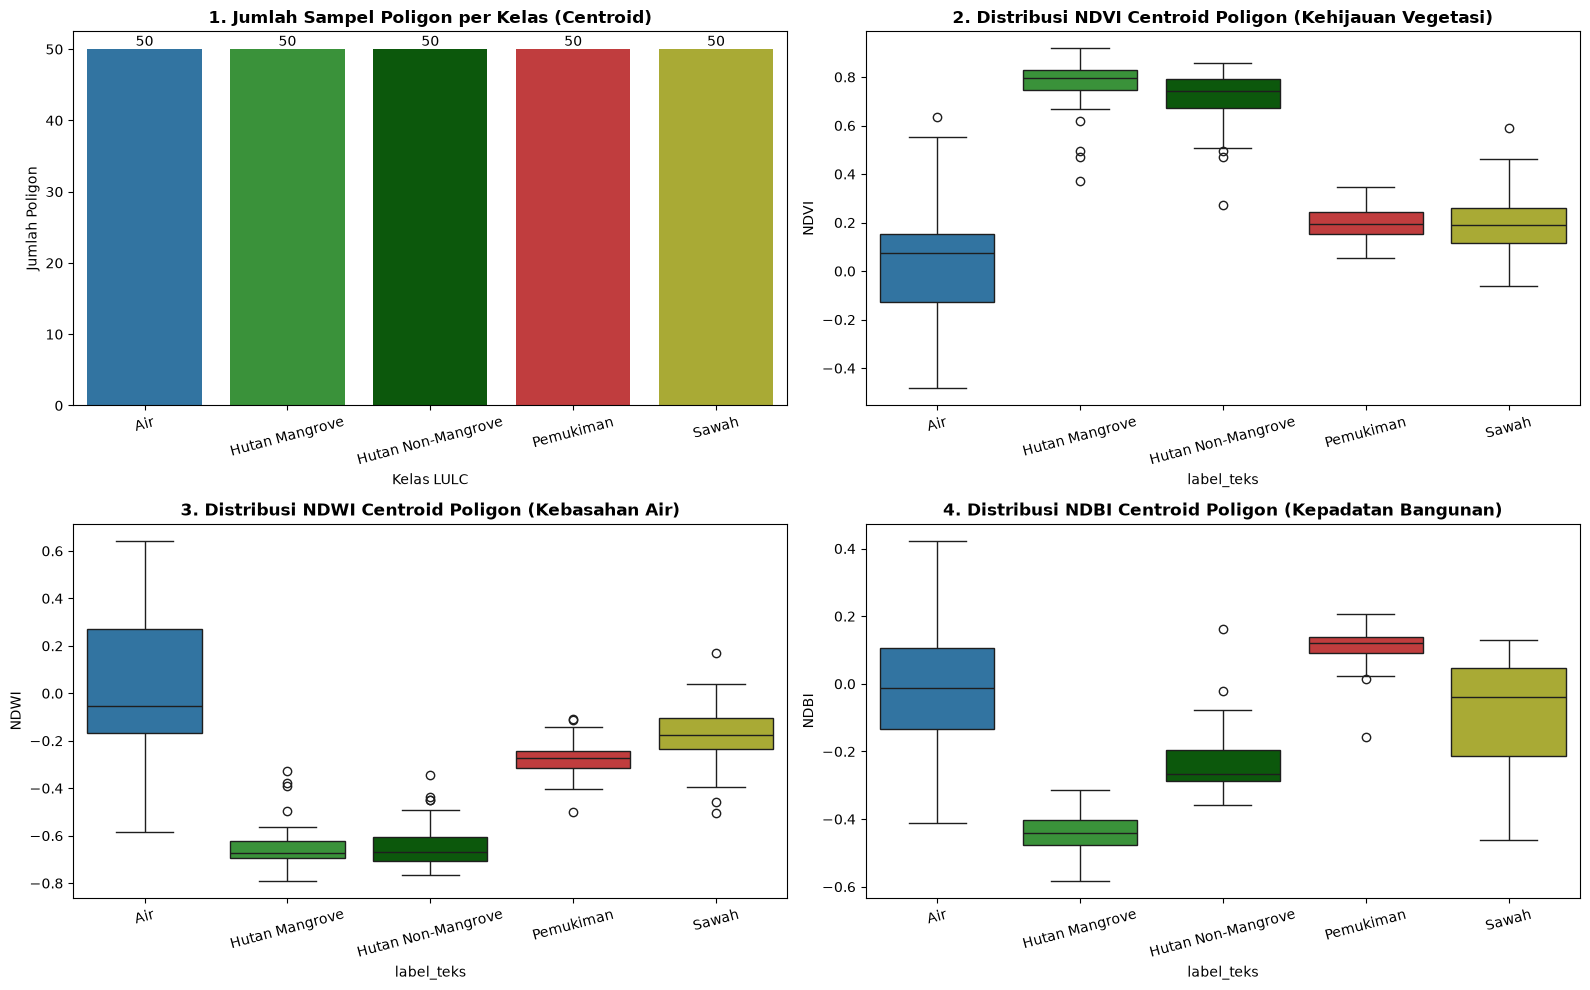

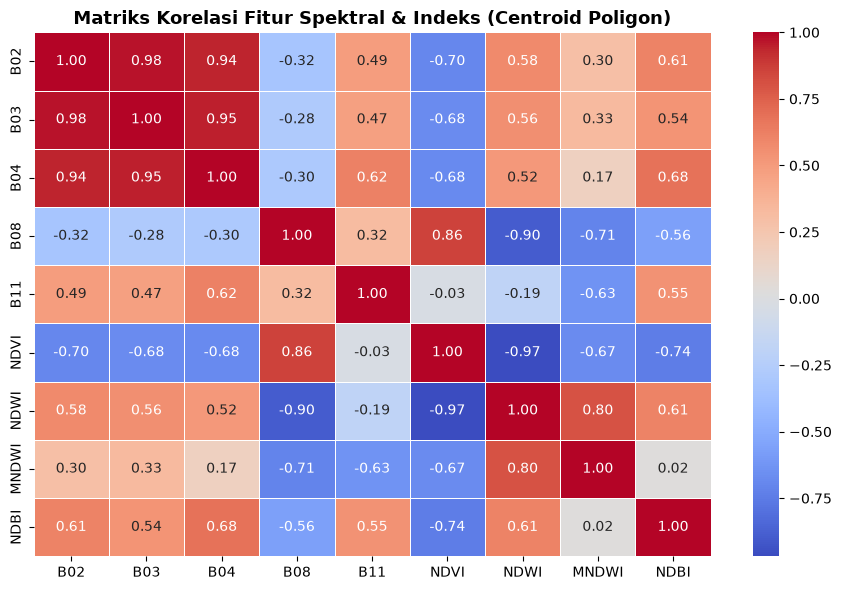

In [195]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette = {
    'Air': '#1f77b4', 
    'Hutan Mangrove': '#2ca02c', 
    'Hutan Non-Mangrove': '#006400', 
    'Pemukiman': '#d62728', 
    'Sawah': '#bcbd22'
}

# 1. Countplot Sampel Poligon Centroid
ax = sns.countplot(data=cen, x='label_teks', palette=palette, ax=axes[0, 0])
axes[0, 0].set_title('1. Jumlah Sampel Poligon per Kelas (Centroid)', fontweight='bold')
axes[0, 0].set_xlabel('Kelas LULC')
axes[0, 0].set_ylabel('Jumlah Poligon')
axes[0, 0].tick_params(axis='x', rotation=15)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

# 2. Boxplot NDVI (Centroid Poligon)
sns.boxplot(data=cen, x='label_teks', y='NDVI', palette=palette, ax=axes[0, 1])
axes[0, 1].set_title('2. Distribusi NDVI Centroid Poligon (Kehijauan Vegetasi)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Boxplot NDWI (Centroid Poligon)
sns.boxplot(data=cen, x='label_teks', y='NDWI', palette=palette, ax=axes[1, 0])
axes[1, 0].set_title('3. Distribusi NDWI Centroid Poligon (Kebasahan Air)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Boxplot NDBI (Centroid Poligon)
sns.boxplot(data=cen, x='label_teks', y='NDBI', palette=palette, ax=axes[1, 1])
axes[1, 1].set_title('4. Distribusi NDBI Centroid Poligon (Kepadatan Bangunan)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Heatmap Korelasi Matriks Fitur Centroid Poligon
plt.figure(figsize=(9, 6))
sns.heatmap(cen[FITUR].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Spektral & Indeks (Centroid Poligon)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Inspeksi Data Training, Data Testing, dan Penjelasan Fitur Spektral

Cell ini menampilkan 5 baris data teratas (`head()`) dari hasil pemisahan **Data Latih (Training Set)** dan **Data Uji (Testing Set)** untuk memverifikasi kesiapan data sebelum masuk ke tahap pemodelan.

### Rincian 9 Fitur Spektral yang Digunakan (`FITUR`)

Dalam alur klasifikasi tutupan lahan (LULC), digunakan 9 fitur spektral yang dideklarasikan sebagai berikut:

```python
FITUR = ['B02', 'B03', 'B04', 'B08', 'B11', 'NDVI', 'NDWI', 'MNDWI', 'NDBI']
```

Berikut adalah rincian 5 band spektral satelit Sentinel-2 dan 4 indeks spektral terhitung beserta alasan pemilihan, formula matematika, dan kegunaannya:

---

### 1. Band Spektral Satelit Sentinel-2 (5 Fitur)

1. **`B02` (Blue - Panjang Gelombang ~490 nm):**
   - **Alasan Penggunaan:** Mengukur pantulan gelombang tampak biru. Band ini sensitif terhadap penyerapan atmosfer, pemetaan perairan dangkal, serta pembeda tanah terbuka.
2. **`B03` (Green - Panjang Gelombang ~560 nm):**
   - **Alasan Penggunaan:** Mengukur puncak pantulan gelombang hijau pada kanopi tumbuhan dan air jernih. Digunakan sebagai komponen penyusun utama indeks kebasahan air NDWI dan MNDWI.
3. **`B04` (Red - Panjang Gelombang ~665 nm):**
   - **Alasan Penggunaan:** Mengukur pita penyerapan utama klorofil $a$ pada tanaman untuk fotosintesis. Digunakan sebagai pembagi utama pada perhitungan indeks vegetasi NDVI.
4. **`B08` (NIR / Near Infrared - Panjang Gelombang ~842 nm):**
   - **Alasan Penggunaan:** Memiliki tingkat reflektansi sangat tinggi pada struktur selular daun vegetasi sehat dan diserap hampir sempurna oleh badan air. Sangat krusial untuk memisahkan vegetasi dari air dan lahan terbangun.
5. **`B11` (SWIR / Shortwave Infrared - Panjang Gelombang ~1610 nm):**
   - **Alasan Penggunaan:** Memiliki daya pantul tinggi pada material buatan (beton, atap seng, aspal) dan tanah kering, namun diserap kuat oleh kandungan air pada kanopi daun dan perairan. Digunakan sebagai komponen utama NDBI dan MNDWI.

---

### 2. Indeks Spektral Terhitung (4 Fitur)

#### A. NDVI (Normalized Difference Vegetation Index)
- **Formulasi Matematika:**

$$\text{NDVI} = \frac{\text{B08} - \text{B04}}{\text{B08} + \text{B04}}$$

- **Kegunaan & Alasan Penggunaan:** Mengukur kerapatan dan tingkat kehijauan vegetasi. Memisahkan kelas Hutan Non-Mangrove dan Hutan Mangrove (NDVI bernilai positif tinggi, $0.6 - 0.8$) dari kelas non-vegetasi seperti Pemukiman dan Air (NDVI mendekati 0 atau negatif).

#### B. NDWI (Normalized Difference Water Index)
- **Formulasi Matematika:**

$$\text{NDWI} = \frac{\text{B03} - \text{B08}}{\text{B03} + \text{B08}}$$

- **Kegunaan & Alasan Penggunaan:** Memetakan keberadaan badan air (sungai, laut, waduk, tambak). Air memantulkan gelombang Hijau (B03) dan menyerap gelombang NIR (B08), sehingga kelas Air menghasilkan nilai NDWI positif paling tinggi ($> 0.3$).

#### C. MNDWI (Modified Normalized Difference Water Index)
- **Formulasi Matematika:**

$$\text{MNDWI} = \frac{\text{B03} - \text{B11}}{\text{B03} + \text{B11}}$$

- **Kegunaan & Alasan Penggunaan:** Modifikasi NDWI dengan menggantikan NIR menjadi SWIR (B11) untuk menekan *noise* dari area pemukiman/bangunan, sehingga perairan di sekitar wilayah perkotaan terpisahkan secara jauh lebih presisi.

#### D. NDBI (Normalized Difference Built-up Index)
- **Formulasi Matematika:**

$$\text{NDBI} = \frac{\text{B11} - \text{B08}}{\text{B11} + \text{B08}}$$

- **Kegunaan & Alasan Penggunaan:** Memetakan area terbangun / pemukiman. Material bangunan (beton, atap, aspal) memiliki reflektansi SWIR (B11) yang melebihi NIR (B08), membuat NDBI menjadi pembeda utama kelas Pemukiman ($> 0.1$) dari kelas vegetasi dan air (NDBI negatif).


In [196]:
print(f" === PREVIEW 5 DATA TRAINING TERATAS ({len(train_cen)} Poligon) ===")
display(train_cen.head())

print(f"\n === PREVIEW 5 DATA TESTING TERATAS ({len(test_cen)} Poligon) ===")
display(test_cen.head())

 === PREVIEW 5 DATA TRAINING TERATAS (175 Poligon) ===


,poligon_id,label,label_teks,n_piksel,lon_centroid,lat_centroid,B02,B03,B04,B08,B11,NDVI,NDWI,MNDWI,NDBI
70,Hutan Mangrove_0020,5,Hutan Mangrove,354,112.835072,-7.348681,327.816384,716.807910,375.615819,4008.093220,1517.564972,0.828482,-0.696475,-0.358242,-0.450630
235,Sawah_0035,1,Sawah,11,112.578269,-7.065253,612.272727,866.272727,810.727273,1402.000000,1053.545455,0.259500,-0.226873,-0.090809,-0.139442
74,Hutan Mangrove_0024,5,Hutan Mangrove,157,112.834894,-7.351455,316.885350,688.579618,369.025478,3845.605096,1489.331210,0.824530,-0.695977,-0.367479,-0.441346
73,Hutan Mangrove_0023,5,Hutan Mangrove,363,112.837253,-7.351224,455.424242,779.234160,541.316804,3079.702479,1385.066116,0.667482,-0.564719,-0.265185,-0.375219
30,Air_0030,4,Air,903,112.266900,-7.203904,816.227021,908.882614,717.349945,579.102990,352.765227,-0.116526,0.231412,0.447929,-0.241183



 === PREVIEW 5 DATA TESTING TERATAS (75 Poligon) ===


,poligon_id,label,label_teks,n_piksel,lon_centroid,lat_centroid,B02,B03,B04,B08,B11,NDVI,NDWI,MNDWI,NDBI
231,Sawah_0031,1,Sawah,4,112.586473,-7.071711,849.250000,1165.500000,1175.750000,1249.000000,813.750000,0.034843,-0.030106,0.188928,-0.218499
38,Air_0038,4,Air,28,112.607866,-7.275806,363.392857,443.250000,370.321429,538.214286,845.392857,0.152948,-0.061623,-0.285753,0.227165
7,Air_0007,4,Air,70,112.563837,-7.026905,1102.457143,1290.400000,1420.814286,1718.314286,2075.714286,0.092976,-0.139947,-0.233763,0.096161
53,Hutan Mangrove_0003,5,Hutan Mangrove,67,113.515143,-7.241364,273.283582,528.716418,303.820896,3074.149254,989.776119,0.818150,-0.704885,-0.304702,-0.510930
10,Air_0010,4,Air,198,112.555941,-7.023457,1187.904040,1392.166667,1524.353535,1730.414141,2125.308081,0.062608,-0.108250,-0.209653,0.103830


## Step 6: Pemodelan Machine Learning (k-Nearest Neighbors - k-NN)

Pada tahap ini digunakan algoritma Machine Learning **k-Nearest Neighbors (k-NN)** untuk mengklasifikasikan 5 kelas tutupan lahan berbasis fitur spektral satelit Sentinel-2.

### Konsep Dasar k-NN
k-NN adalah algoritma pembelajaran terawasi (*supervised learning*) non-parametrik yang bekerja berdasarkan prinsip kedekatan jarak (*proximity*). Algoritma ini mengasumsikan bahwa objek dengan karakteristik spektral yang serupa akan berada berdekatan dalam ruang fitur $n$-dimensi.

Proses klasifikasi k-NN:
1. Menghitung jarak geometri antara sampel baru dengan seluruh sampel data training.
2. Mengurutkan jarak dan memilih $k$ sampel tetangga terdekat.
3. Melakukan voting suara mayoritas (*majority voting*) untuk menentukan kelas tutupan lahan sampel baru.

### Peran Penting Preprocessing StandardScaler
Karena k-NN sangat bergantung pada perhitungan jarak geometri, fitur spektral dengan rentang nilai nominal besar (seperti panjang gelombang B08/B11) dapat mendominasi perhitungan jarak dibanding fitur bernilai kecil (seperti indeks NDVI yang bernilai $[-1, 1]$). Oleh karena itu, penerapan `StandardScaler()` wajib dilakukan untuk menyamakan skala seluruh fitur (rata-rata $= 0$, varians $= 1$).

### Landasan Matematika k-NN

#### 1. Formulasi Jarak Euclidean (Euclidean Distance)
Jarak geometri Euclidean antara dua vektor fitur spektral $\mathbf{x}$ dan $\mathbf{y}$ dalam ruang $n$-dimensi ($n=9$ fitur spektral) didefinisikan sebagai:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Keterangan:
- $\mathbf{x}$ dan $\mathbf{y}$: Vektor fitur spektral dari dua sampel poligon.
- $x_i, y_i$: Nilai fitur spektral ke-$i$ (misalnya nilai NDVI, NDWI, B08, dll.).
- $n$: Jumlah total fitur spektral ($n=9$).

#### 2. Formulasi Jarak Manhattan (City Block Distance)
Sebagai perbandingan metrik jarak linier:

$$d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$$

#### 3. Fungsi Keputusan Voting Mayoritas (Majority Voting)
Setelah $k$ tetangga terdekat $N_k(\mathbf{x})$ ditemukan, label kelas $\hat{y}$ ditentukan berdasarkan frekuensi terbanyak:

$$\hat{y} = \arg\max_{c \in C} \sum_{i \in N_k(\mathbf{x})} I(y_i = c)$$

Keterangan:
- $C$: Himpunan 5 kelas tutupan lahan target.
- $N_k(\mathbf{x})$: Himpunan $k$ tetangga terdekat dari sampel $\mathbf{x}$.
- $I(\cdot)$: Fungsi indikator (bernilai 1 jika $y_i = c$, dan 0 jika lainnya).


In [197]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_train, y_train = train_cen[FITUR], train_cen['label_teks']
X_test, y_test = test_cen[FITUR], test_cen['label_teks']

print("Melatih Model k-Nearest Neighbors (k-NN Scaled)...")
# Menggunakan k-NN Scaled dengan k=5 dan pembobotan berbasis jarak (distance-weighted)
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
)
knn_model.fit(X_train, y_train)
print("[OK] Model k-NN berhasil dilatih!")


Melatih Model k-Nearest Neighbors (k-NN Scaled)...
[OK] Model k-NN berhasil dilatih!


## Step 7: Evaluasi Kinerja Model k-NN (Akurasi, Cohen's Kappa, Confusion Matrix, dan Analisis Nilai k)

Cell ini menguji performa prediksi model k-NN terhadap **Data Uji (Test Set)** sebanyak 75 poligon (30% dari total dataset). Evaluasi mencakup:
1. **Overall Accuracy & Cohen's Kappa Index:** Mengukur akurasi keseluruhan dan konsistensi prediksi.
2. **Classification Report:** Menilai Precision, Recall, dan F1-Score per kelas tutupan lahan.
3. **Confusion Matrix Heatmap:** Menunjukkan matriks perbandingan prediksi vs aktual.
4. **Grafik Analisis Variasi Nilai k (Validation Curve):** Menguji performa akurasi pada variasi $k=1$ hingga $k=15$ untuk menemukan jumlah tetangga paling optimal.


MODEL k-NN SCALED (k=5) -> Overall Accuracy: 80.00% | Cohen Kappa: 0.7500
=== CLASSIFICATION REPORT (k-NN) ===
                    precision    recall  f1-score   support

               Air       0.70      0.47      0.56        15
    Hutan Mangrove       1.00      0.93      0.97        15
Hutan Non-Mangrove       0.88      1.00      0.94        15
         Pemukiman       0.93      0.93      0.93        15
             Sawah       0.53      0.67      0.59        15

          accuracy                           0.80        75
         macro avg       0.81      0.80      0.80        75
      weighted avg       0.81      0.80      0.80        75



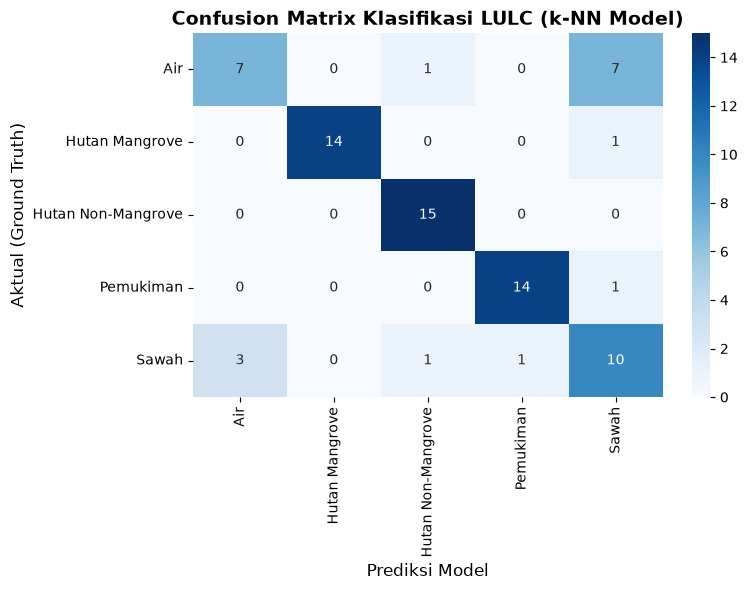

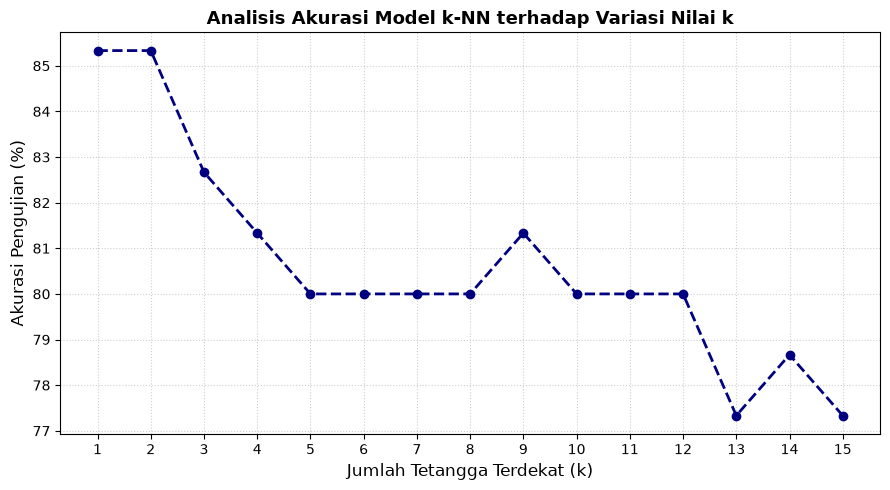

In [198]:
# Prediksi Data Uji
y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
kappa_knn = cohen_kappa_score(y_test, y_pred_knn)

print("===========================================================")
print(f"MODEL k-NN SCALED (k=5) -> Overall Accuracy: {acc_knn*100:.2f}% | Cohen Kappa: {kappa_knn:.4f}")
print("===========================================================")

print("=== CLASSIFICATION REPORT (k-NN) ===")
print(classification_report(y_test, y_pred_knn))

# 1. Confusion Matrix Heatmap
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_model.classes_, 
            yticklabels=knn_model.classes_)
plt.title('Confusion Matrix Klasifikasi LULC (k-NN Model)', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Aktual (Ground Truth)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Grafik Analisis Variasi Nilai k (Validation Curve k=1 hingga k=15)
k_range = range(1, 16)
acc_scores = []

for k_val in k_range:
    temp_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_val, weights='distance'))
    temp_knn.fit(X_train, y_train)
    acc_scores.append(accuracy_score(y_test, temp_knn.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(k_range, [acc * 100 for acc in acc_scores], marker='o', color='navy', linestyle='--', linewidth=2)
plt.title('Analisis Akurasi Model k-NN terhadap Variasi Nilai k', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Tetangga Terdekat (k)', fontsize=12)
plt.ylabel('Akurasi Pengujian (%)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Step 8: Menyimpan Model k-NN Terlatih (Model Export)
Cell ini menyimpan file model k-NN terlatih (`model_lulc_knn.pkl`) ke folder `../models/` menggunakan `joblib` agar dapat dimuat oleh aplikasi web Streamlit untuk inferensi tutupan lahan.


In [199]:
output_dir = '../models'
os.makedirs(output_dir, exist_ok=True)

knn_export_path = os.path.join(output_dir, 'model_lulc_knn.pkl')
joblib.dump(knn_model, knn_export_path)

print(f"[OK] Model k-NN berhasil disimpan di: {knn_export_path}")


[OK] Model k-NN berhasil disimpan di: ../models\model_lulc_knn.pkl


## Step 9: Peta Klasifikasi LULC Hasil Prediksi Model ML (Diferensiasi Prediksi Benar vs Prediksi Salah/ORANGE)

Cell ini memetakan **hasil prediksi model Machine Learning** (`knn_model`) ke atas peta interaktif Folium dengan pembedaan warna khusus:
- **Prediksi Benar (Match):** Titik lokasi yang berhasil diprediksi secara benar oleh model ML diwarnai sesuai kode warna resmi kelas LULC (Biru = Air, Hijau Terang = Mangrove, Hijau Tua = Hutan, Merah = Pemukiman, Kuning = Sawah).
- **Prediksi Salah (Mismatch - ORANGE):** Titik lokasi yang diprediksi salah / tertukar oleh model ML diwarnai **ORANYE (`#ff7f0e`)** agar pengguna dapat langsung mendeteksi area mana saja yang membingungkan bagi model ML.
- **LayerControl Interaktif:** Dilengkapi layer khusus `⚠️ Prediksi Salah / Mismatch (ORANGE)` yang dapat di-centang atau disembunyikan.


In [200]:
# 1. Evaluasi Hasil Prediksi Model k-NN pada Seluruh Sampel Centroid
cen['prediksi_ml'] = knn_model.predict(cen[FITUR])
cen['is_correct'] = cen['prediksi_ml'] == cen['label_teks']

n_correct = cen['is_correct'].sum()
n_mismatch = (~cen['is_correct']).sum()

print("=== RINGKASAN EVALUASI PREDIKSI MODEL ML PADA PETA JAWA TIMUR ===")
print(f"Total Sampel Poligon Centroid : {len(cen)}")
print(f"Prediksi Benar (Match)        : {n_correct} Poligon ({n_correct/len(cen)*100:.2f}%)")
print(f"Prediksi Salah (ORANGE/Mismatch): {n_mismatch} Poligon ({n_mismatch/len(cen)*100:.2f}%)")
print("=================================================================")

# 2. Inisialisasi Peta Folium Klasifikasi Spasial LULC Jawa Timur (Step 9)
m_pred = folium.Map(
    location=[-7.60, 112.60],
    zoom_start=9,
    tiles=None
)

# Basemap Google Hybrid & Esri World Imagery Satelit
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Hybrid',
    name='Google Hybrid (dengan label)',
    overlay=False,
    control=True
).add_to(m_pred)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Esri Satellite (online)',
    overlay=False,
    control=True
).add_to(m_pred)

folium.TileLayer('openstreetmap', name='OpenStreetMap Standard').add_to(m_pred)

# 3. Layer Raster Overlay Klasifikasi Spasial Tutupan Lahan Se-Jawa Timur
img_path = '../assets/peta_klasifikasi.png'
if os.path.exists(img_path):
    import base64
    with open(img_path, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode('utf-8')
    img_url = f"data:image/png;base64,{img_b64}"
    
    bounds = [[-7.35, 112.25], [-6.95, 112.85]]
    folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=bounds,
        name='Hasil Klasifikasi Model ML (Raster Grid)',
        opacity=0.75,
        overlay=True,
        control=True
    ).add_to(m_pred)

# 4. Batas Area Studi (Provinsi Jawa Timur)
geojson_prov_path = os.path.normpath('../data/geojson/jawa_timur_provinsi.geojson')
if os.path.exists(geojson_prov_path):
    folium.GeoJson(
        geojson_prov_path,
        name='Batas area studi',
        style_function=lambda x: {
            'color': '#ff7800',
            'weight': 2.5,
            'dashArray': '5, 5',
            'fillOpacity': 0.03
        }
    ).add_to(m_pred)

# Kode Warna Resmi per Kelas Tutupan Lahan
class_colors = {
    'Sawah': '#bcbd22',               # Kuning/Zaitun
    'Pemukiman': '#d62728',          # Merah (Bangunan)
    'Hutan Mangrove': '#2ca02c',      # Hijau Terang / Mangrove
    'Hutan Non-Mangrove': '#006400',   # Hijau Tua / Lahan Hijau
    'Air': '#1f77b4'                 # Biru / Perairan
}

COLOR_ORANGE = '#ff7f0e'  # Warna Khusus Prediksi Salah / Mismatch

# 5. Layer Sampel Point Markers PER KELAS (Match / Benar)
for class_name, color in class_colors.items():
    sub_df = cen[(cen['prediksi_ml'] == class_name) & (cen['is_correct'])]
    if not sub_df.empty:
        fg = folium.FeatureGroup(name=f"Sampel: {class_name} ({len(sub_df)} Titik)", show=True)
        
        for idx, row in sub_df.iterrows():
            tooltip_html = f"""
            <div style="font-family: sans-serif; font-size: 11px; width: 220px;">
                <b style="font-size: 12px; color: #1E3A8A;">{row['prediksi_ml']}</b><br>
                (lon {row['lon_centroid']:.4f}, lat {row['lat_centroid']:.4f})<br>
                <hr style="margin: 2px 0;">
                <b>Hasil Prediksi ML:</b> <span style="color: {color}; font-weight: bold;">{row['prediksi_ml']}</span><br>
                <b>Label Aktual:</b> {row['label_teks']}<br>
                <b style="color: #2ca02c;">Status: PREDIKSI BENAR (MATCH)</b><br>
                <hr style="margin: 2px 0;">
                NDVI: <b>{row['NDVI']:.3f}</b> | NDWI: <b>{row['NDWI']:.3f}</b> | NDBI: <b>{row['NDBI']:.3f}</b>
            </div>
            """
            
            folium.CircleMarker(
                location=[row['lat_centroid'], row['lon_centroid']],
                radius=7.5,
                color='#ffffff',
                fill=True,
                fill_color=color,
                fill_opacity=0.9,
                weight=1.5,
                popup=folium.Popup(tooltip_html, max_width=250),
                tooltip=f"{row['prediksi_ml']} (lon {row['lon_centroid']:.4f}, lat {row['lat_centroid']:.4f})"
            ).add_to(fg)
            
        fg.add_to(m_pred)

# 6. Layer Khusus Titik Prediksi Salah / Mismatch (ORANGE)
df_mismatch = cen[~cen['is_correct']]
if not df_mismatch.empty:
    fg_mismatch = folium.FeatureGroup(name=f"⚠️ Sampel Mismatch (ORANGE - {len(df_mismatch)} Titik)", show=True)
    
    for idx, row in df_mismatch.iterrows():
        tooltip_html = f"""
        <div style="font-family: sans-serif; font-size: 11px; width: 230px; background-color: #FFF5EE; padding: 4px; border-radius: 4px;">
            <b style="font-size: 12px; color: #d62728;">⚠️ PREDIKSI SALAH (MISMATCH)</b><br>
            (lon {row['lon_centroid']:.4f}, lat {row['lat_centroid']:.4f})<br>
            <hr style="margin: 2px 0;">
            <b>Prediksi Model ML:</b> <span style="color: {COLOR_ORANGE}; font-weight: bold;">{row['prediksi_ml']}</span><br>
            <b>Seharusnya (Aktual):</b> <b>{row['label_teks']}</b><br>
            <hr style="margin: 2px 0;">
            NDVI: <b>{row['NDVI']:.3f}</b> | NDWI: <b>{row['NDWI']:.3f}</b> | NDBI: <b>{row['NDBI']:.3f}</b>
        </div>
        """
        
        folium.CircleMarker(
            location=[row['lat_centroid'], row['lon_centroid']],
            radius=9,
            color='#d62728',
            fill=True,
            fill_color=COLOR_ORANGE,
            fill_opacity=0.95,
            weight=2.5,
            popup=folium.Popup(tooltip_html, max_width=260),
            tooltip=f"⚠️ MISMATCH: Model={row['prediksi_ml']} | Aktual={row['label_teks']}"
        ).add_to(fg_mismatch)
        
    fg_mismatch.add_to(m_pred)

# 7. Legenda LULC Melayang di Kiri Bawah Peta
legend_html = f'''
<div style="
    position: fixed; 
    bottom: 20px; left: 20px; width: 195px; 
    border: 1px solid #cbd5e1; z-index: 99999; font-size: 11px;
    background-color: rgba(255, 255, 255, 0.94); padding: 8px 10px;
    border-radius: 8px; font-family: sans-serif;
    box-shadow: 0 3px 8px rgba(0,0,0,0.3);
">
    <b style="font-size: 12px; color: #1E3A8A;">Legenda LULC</b>
    <hr style="margin: 4px 0;">
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:{class_colors['Sawah']}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Sawah (Crops)</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:{class_colors['Pemukiman']}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Bangunan (Pemukiman)</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:{class_colors['Hutan Mangrove']}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Hutan Mangrove</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:{class_colors['Hutan Non-Mangrove']}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Hutan Non-Mangrove</b>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="background:{class_colors['Air']}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #999;"></span>
        <b>Air (Perairan)</b>
    </div>
    <hr style="margin: 4px 0;">
    <div style="display:flex; align-items:center; color:#d62728;">
        <span style="background:{COLOR_ORANGE}; width:12px; height:12px; display:inline-block; margin-right:6px; border-radius:2px; border:1px solid #d62728;"></span>
        <b>⚠️ Mismatch ORANGE ({n_mismatch})</b>
    </div>
</div>
'''
m_pred.get_root().html.add_child(folium.Element(legend_html))

# 8. Layer Control Panel Interaktif (Terbuka agar pengguna dapat memilih layer)
folium.LayerControl(collapsed=False).add_to(m_pred)

# Simpan Peta Hasil Klasifikasi ML ke File HTML
html_file_pred = 'map_lulc_predicted.html'
m_pred.save(html_file_pred)

# Tampilkan Peta di Jupyter Notebook
display(m_pred)


=== RINGKASAN EVALUASI PREDIKSI MODEL ML PADA PETA JAWA TIMUR ===
Total Sampel Poligon Centroid : 250
Prediksi Benar (Match)        : 235 Poligon (94.00%)
Prediksi Salah (ORANGE/Mismatch): 15 Poligon (6.00%)
